<a href="https://colab.research.google.com/github/shahed-maumer/Machine-Learning-/blob/main/Copy_of_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#shahed maumer
#Machine Learning Assignment 1

In [ ]:
#Libraries
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings("ignore")
#Import all required libraries for data manipulation, visualization, and machine learning preprocessing.

In [ ]:
#Upload Data
from google.colab import files
uploaded = files.upload()
#Upload the dataset files (train.csv and test.csv) from the local machine into Google Colab

Saving train.csv to train (3).csv
Saving test.csv to test (3).csv


In [ ]:
#Load Data
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print(train.shape, test.shape)
#Load the training and testing datasets and display their dimensions.

(1460, 81) (1459, 80)


In [ ]:
#Preview Data
train.head()

#Display the first rows of the dataset to understand its structure.

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
#Missing Values
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing
#Identify and list all columns that contain missing values.

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageType,81
GarageYrBlt,81
GarageFinish,81


In [ ]:
#Handle Missing Values
cat_cols_none = ["PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu"]

for col in cat_cols_none:
    if col in train.columns:
        train[col] = train[col].astype("object")
        train[col] = train[col].fillna("None")

for col in train.select_dtypes(include=np.number).columns:
    train[col] = train[col].fillna(train[col].median())
#Fill categorical missing values with "None" and numerical missing values with median.

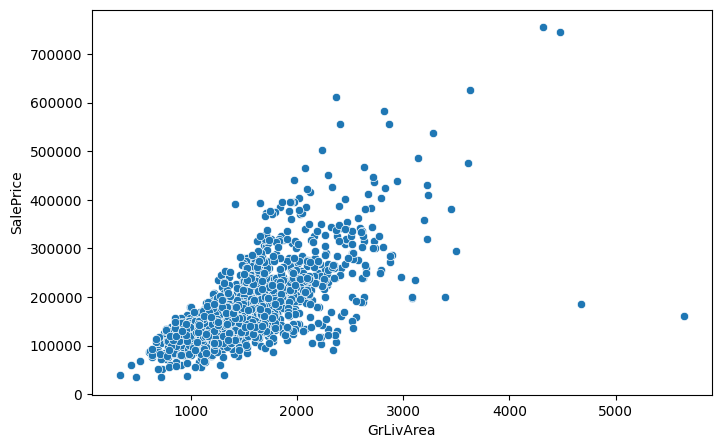

In [ ]:
#Outliers Visualization
plt.figure(figsize=(8,5))
sns.scatterplot(x=train["GrLivArea"], y=train["SalePrice"])
plt.show()
#Visualize potential outliers in the relationship between living area and house price.

In [ ]:
#Remove Outliers
train = train[train["GrLivArea"] < 4500]
#Remove extreme outliers to improve model performance.

In [ ]:
#Log Transformation
train["SalePrice"] = np.log1p(train["SalePrice"])
#Normalize the target variable using log transformation to reduce skewness.

In [ ]:
#Neighborhood EDA
fig = px.box(train, x="Neighborhood", y="SalePrice")
fig.show()
#Analyze how house prices vary across different neighborhoods.

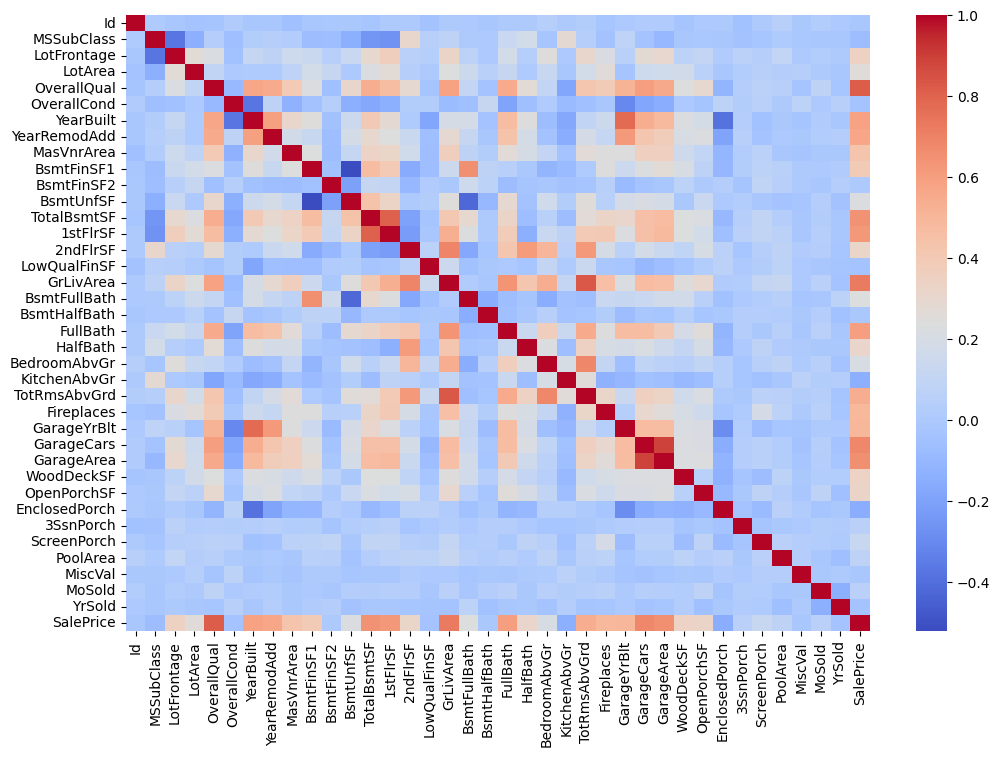

In [ ]:
#Correlation Heatmap
corr = train.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm")
plt.show()
#Visualize correlation between numerical features in the dataset.

In [ ]:
#Top Features
corr["SalePrice"].sort_values(ascending=False).head(6)
#Identify the most important features correlated with house price.

,SalePrice
SalePrice,1.000000
OverallQual,0.821405
GrLivArea,0.725211
GarageCars,0.681033
GarageArea,0.656129
TotalBsmtSF,0.647563


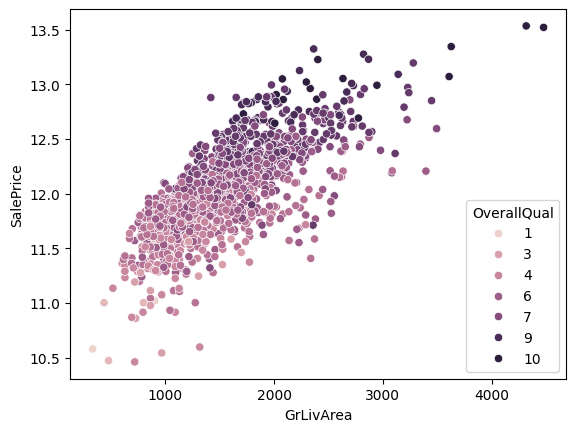

In [ ]:
#Scatter Plot
sns.scatterplot(
    data=train,
    x="GrLivArea",
    y="SalePrice",
    hue="OverallQual"
)
plt.show()
#Show relationship between living area and price grouped by quality.

In [ ]:
#Feature Engineering
train["TotalSF"] = train["TotalBsmtSF"] + train["1stFlrSF"] + train["2ndFlrSF"]
test["TotalSF"] = test["TotalBsmtSF"] + test["1stFlrSF"] + test["2ndFlrSF"]

#Create a new feature representing total house area.

In [ ]:
#Label Encoding
ordinal = ["ExterQual", "KitchenQual"]

le = LabelEncoder()

for col in ordinal:
    train[col] = le.fit_transform(train[col].astype(str))
    test[col] = le.fit_transform(test[col].astype(str))

#Convert ordinal categorical variables into numerical values while preserving order.

In [ ]:
#One-Hot Encoding
nominal = ["Neighborhood", "BldgType"]

train = pd.get_dummies(train, columns=nominal)
test = pd.get_dummies(test, columns=nominal)

test = test.reindex(columns=train.columns, fill_value=0)
#Convert nominal categorical variables into binary features for machine learning models.

In [ ]:
#Preprocessing Function
def preprocess(df):
    df = df.copy()

    df["TotalSF"] = df["TotalBsmtSF"] + df["1stFlrSF"] + df["2ndFlrSF"]

    for col in cat_cols_none:
        if col in df.columns:
            df[col] = df[col].astype("object")
            df[col] = df[col].fillna("None")

    for col in df.select_dtypes(include=np.number).columns:
        df[col] = df[col].fillna(df[col].median())

    return df

#Create a reusable preprocessing pipeline for consistent cleaning of train and test datasets.

In [ ]:
#Apply Pipeline
train_processed = preprocess(train)
test_processed = preprocess(test)

print(train_processed.shape, test_processed.shape)
#Apply preprocessing pipeline and verify final dataset shape.

(1458, 82) (1459, 81)
